# Atividade 2.1 - Solução de Equações Não Lineares Univariadas

Aluno: Vinicius Batista Duarte

In [276]:
import numpy as np
import matplotlib.pyplot as plt

### 1. Implemente o método da Bisseção descrito pelo algoritmo 1.1 no texto. Para testar o algoritmo, use os exemplos do material textual.

In [277]:
def f(x):
    x_fun = x - 4
    return x_fun

In [278]:
tol = 1e-8

In [279]:
def bissecao(f, a, b, tol):
    if np.sign(f(a)) * np.sign(f(b)) >= 0:
        print("Tem raiz garantida nesse intervalo não, zé")
        return None
    
    n = np.log((b-a)/tol)/np.log(2)
    i = 0
    
    while True:
        #Método da Bisseção
        x = (a + b)/2

        if f(x) == 0:
            return x
            
        if np.sign(f(a)) * np.sign(f(x)) < 0:
            b = x
        else: 
            a = x

        i += 1

        if i >= n:
            return x
            
        if abs(b - a) < tol:
            return x

In [280]:
print(bissecao(f, 0, 9, tol))

4.000000004656613


### 2. Determine as raízes reais de f (x) = −0.5x^2 + 2.5x + 4.5:

#### a) Graficamente

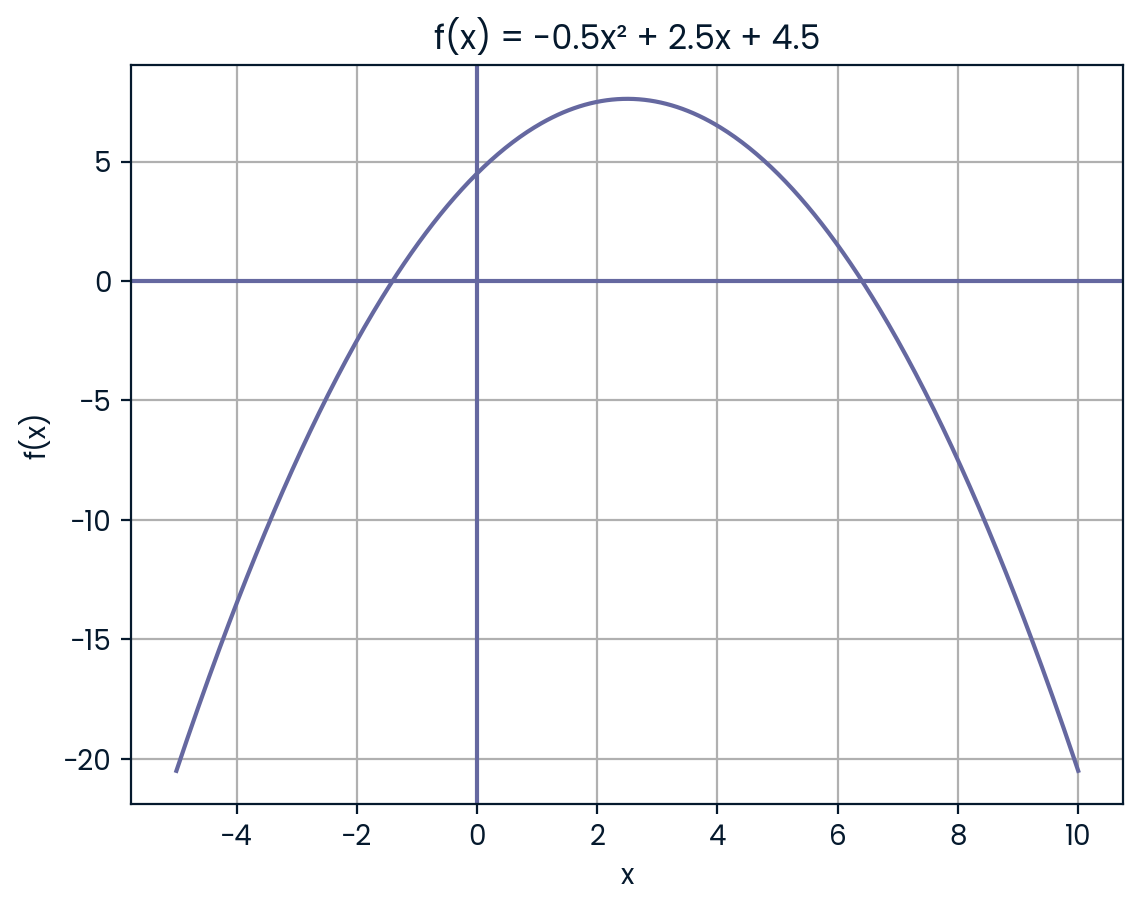

In [281]:
# Valores de x
x = np.linspace(-5, 10, 500)

# Função
f = -0.5*x**2 + 2.5*x + 4.5

# Plot
plt.plot(x, f)

# Eixos
plt.axhline(0)
plt.axvline(0)

# Título e rótulos
plt.title("f(x) = -0.5x² + 2.5x + 4.5")
plt.xlabel("x")
plt.ylabel("f(x)")

plt.grid()
plt.show()

In [282]:
# Analisando Graficamente, podemos notar que a primeira raiz é um valor entre -2 e -1, já a segunda, um valor entre 6 e 7.

#### b) Usando a fórmula quadrática

In [283]:
def bhaskara(a, b, c):
    delta = b**2 - 4*a*c

    xi = (-b + delta**0.5) / (2*a)
    xii = (-b - delta**0.5) / (2*a)

    return xi, xii

In [284]:
print(f"Raizes : {bhaskara(-0.5, 2.5, 4.5)}")

Raizes : (-1.405124837953327, 6.405124837953327)


In [285]:
def f2(x):
    f = -0.5*x**2 + 2.5*x + 4.5
    return f

In [286]:
def bissecao2(f, a, b, tol):
    if np.sign(f(a)) * np.sign(f(b)) >= 0:
        print("Não tem raiz garantida nesse intervalo")
        return None
    
    n = 3
    i = 0
    
    while True:
        #Método da Bisseção
        x = (a + b)/2

        if f(x) == 0:
            return x
            
        if np.sign(f(a)) * np.sign(f(x)) < 0:
            b = x
        else: 
            a = x

        i += 1

        print(f"Iteração: {i} , Valor de a: {a}, Valor de b: {b}, Valor de x: {x}")
        
        if i >= n:
            print(f"Valor de X encontrado: {x}")
            return x
            
            
        if abs(b - a) < tol:
            print(f"Valor de X encontrado: {x}")
            return x

In [287]:
bissecao2(f2, 5, 10, tol)

Iteração: 1 , Valor de a: 5, Valor de b: 7.5, Valor de x: 7.5
Iteração: 2 , Valor de a: 6.25, Valor de b: 7.5, Valor de x: 6.25
Iteração: 3 , Valor de a: 6.25, Valor de b: 6.875, Valor de x: 6.875
Valor de X encontrado: 6.875


6.875

In [288]:
import pandas as pd

In [289]:
def bissecao3(f, a, b, tol):
    if np.sign(f(a)) * np.sign(f(b)) >= 0:
        print("Não tem raiz garantida nesse intervalo")
        return None

    n  = 3
    i = 0
    dados = []
    x_anterior = 0

    while True:
        x = (a + b) / 2

        if f(x) == 0:
            break

        if np.sign(f(a)) * np.sign(f(x)) < 0:
            erro = abs((x - x_anterior) / x)
            dados.append([i, a, b, x, erro])
            b = x
        else:
            erro = abs((x - x_anterior) / x)
            dados.append([i, a, b, x, erro])
            a = x

        i += 1
        x_anterior = x
        
        if abs(b - a) < tol:
            break

        if i >= n:
            break

    tabela = pd.DataFrame(
        dados,
        columns=["Iteração", "Valor de a", "Valor de b", "Valor de x", "Erro Relativo"]
    )

    print(tabela)

    return x

In [290]:
bissecao3(f2, 5, 10, tol)

   Iteração  Valor de a  Valor de b  Valor de x  Erro Relativo
0         0        5.00        10.0       7.500       1.000000
1         1        5.00         7.5       6.250       0.200000
2         2        6.25         7.5       6.875       0.090909


6.875

### 3. Localize a primeira raiz não-trivial de sin x = x^3, onde x está em radianos. Use uma técnica gráfica e a bisseção com o intervalo inicial de 0, 5 a 1. Faça os cálculos até que o erro seja inferior a 2%.

In [291]:
def f3(x):
    f = np.sin(x) - x**3
    return f

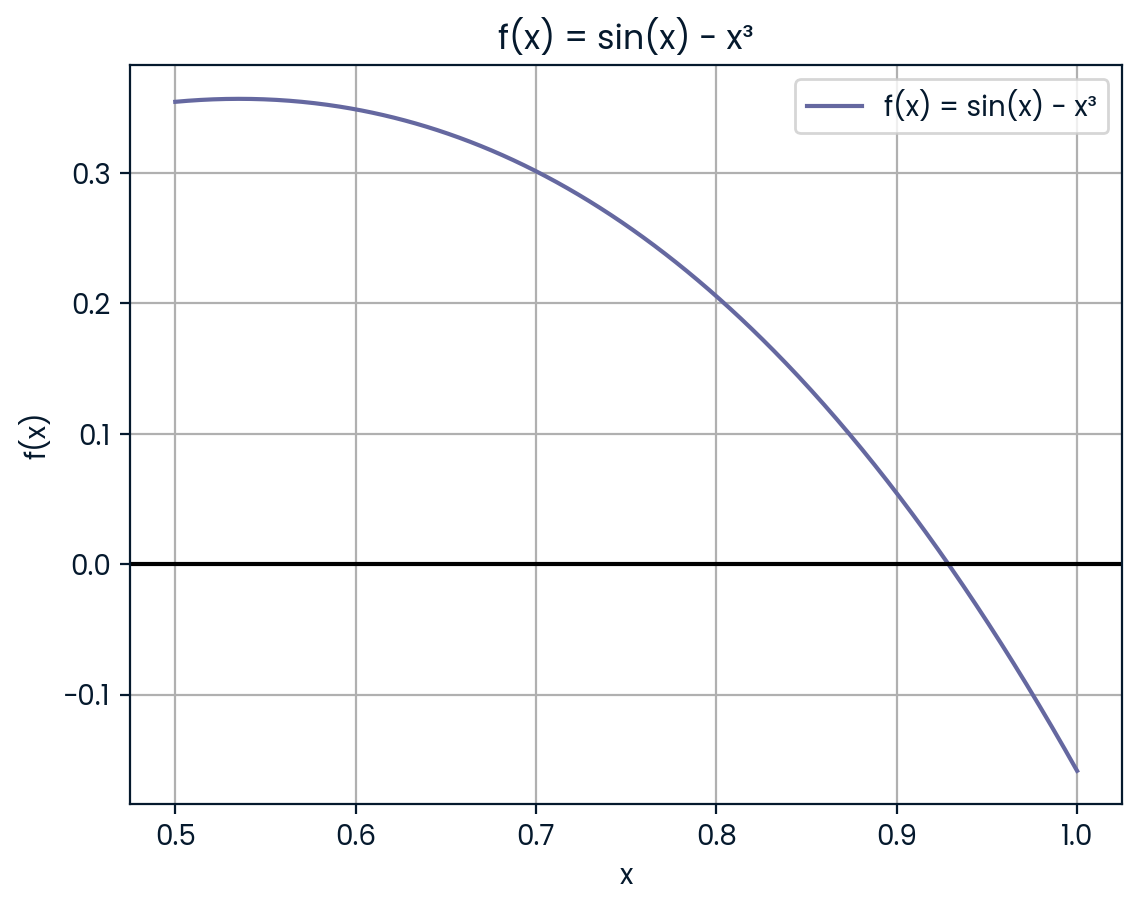

In [292]:
x = np.linspace(0.5, 1, 500)

plt.plot(x, f3(x), label='f(x) = sin(x) - x³')
plt.axhline(0, color='black')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('f(x) = sin(x) - x³')
plt.grid()
plt.legend()

plt.show()

In [293]:
# O gráfico mostra onde a curva cruza o eixo x, indicando visualmente a raiz não trivial próxima de 0,93

In [294]:
tol = 0.02

In [295]:
def bissecao4(f, a, b, tol):
    if np.sign(f(a)) * np.sign(f(b)) >= 0:
        print("Não tem raiz garantida nesse intervalo")
        return None

    n = np.log((b-a)/tol) / np.log(2)
    i = 0
    dados2 = []
    x_anterior = None

    while True:
        x = (a + b) / 2

        if x_anterior is None:
            erro = None
        else:
            erro = abs((x - x_anterior) / x)

        dados2.append([i, a, b, x, erro])

        if f(x) == 0:
            break

        if np.sign(f(a)) * np.sign(f(x)) < 0:
            b = x
        else:
            a = x

        i += 1

        if erro is not None and erro < tol:
            break

        if i >= n:
            break

        x_anterior = x

    tabela = pd.DataFrame(
        dados2,
        columns=["Iteração", "Valor de a", "Valor de b", "Valor de x", "Erro Relativo"]
    )

    print(tabela)

    return x

In [296]:
bissecao4(f3, 0.5, 1, tol)

   Iteração  Valor de a  Valor de b  Valor de x  Erro Relativo
0         0     0.50000      1.0000    0.750000            NaN
1         1     0.75000      1.0000    0.875000       0.142857
2         2     0.87500      1.0000    0.937500       0.066667
3         3     0.87500      0.9375    0.906250       0.034483
4         4     0.90625      0.9375    0.921875       0.016949


0.921875

### 4. Dada f(x) = −2x^6 − 1.5x^4 + 10x + 20, encontre o máximo dessa função ( f'(x) = 0) usando o método da bisseção, considerando o intervalo [0, 1] e um erro limite de 5%.

In [297]:
# Derivamos a f(x) e obtemos f'(x) = -2x + 4, basta aplicar:

In [298]:
def f4(x):
    f = -2*x + 4
    return f

In [299]:
tol = 0.05
bissecao4(f4, 0, 1, tol)

Não tem raiz garantida nesse intervalo


In [300]:
# Para o intervalo estabelecido no enunciado, não há um máximo garantido.

### 5. Embora a bisseção seja uma técnica perfeitamente válida para determinar raízes, sua abordagem do tipo **“força bruta”** é relativamente ineficiente. A falsa posição é uma alternativa baseada na percepção gráfica.

Uma deficiência do método da bisseção é que, na divisão do intervalo de \(x_l\) a \(x_u\) em metades iguais, não são levados em conta os módulos de \(f(x_l)\) e \(f(x_u)\).

Por exemplo, se \(f(x_l)\) estiver muito mais próximo de zero do que \(f(x_u)\), será provável que a raiz esteja mais próxima de \(x_l\) que de \(x_u\).

Um método alternativo que explora essa percepção gráfica é ligar \(f(x_l)\) e \(f(x_u)\) por uma reta. A intersecção dessa reta com o eixo \(x\) representa uma estimativa melhorada da raiz.

O fato da substituição da curva por uma reta dar uma **“falsa posição”** da raiz é a origem do nome **método da falsa posição**, ou, em latim, *regula falsi*. Ele também é chamado de **método da interpolação linear**.

Para esse método, a aproximação da raiz é dada por:

$$
x^* = x_u -
\frac{f(x_u)(x_l-x_u)}
{f(x_l)-f(x_u)}
$$

em que:

- \(x^*\) é a estimação da raiz na atual iteração;
- \(x_l\) é o limite inferior do intervalo de verificação da raiz;
- \(x_u\) é o limite superior do intervalo de verificação da raiz;
- \(f(x_l)\) é o valor da função para o limite inferior;
- \(f(x_u)\) é o valor da função para o limite superior.

As bibliotecas numéricas do Python não trazem uma implementação desse método. **Implemente-o**, teste-o com os exemplos do texto, comparando com o método da bisseção.

Mostre que esse método, para vários casos, é **mais eficiente que o método da bisseção**.

In [301]:
def falsa_posicao(f, xl, xu, tol):
    # Verifica se existe troca de sinal no intervalo
    if np.sign(f(xl)) * np.sign(f(xu)) >= 0:
        print("Não tem raiz garantida nesse intervalo")
        return None

    i = 0
    x_anterior = None
    dados = []

    while True:

        # Fórmula da falsa posição
        x = xu - (f(xu) * (xl - xu)) / (f(xl) - f(xu))

        # Calcula o erro relativo
        if x_anterior is None:
            erro = None
        else:
            erro = abs((x - x_anterior) / x)

        dados.append([i, xl, xu, x, f(x), erro])

        # Verifica se encontrou exatamente a raiz
        if f(x) == 0:
            break

        # Verifica em qual subintervalo está a raiz
        if np.sign(f(xl)) * np.sign(f(x)) < 0:
            xu = x
        else:
            xl = x

        i += 1

        # Critério de parada
        if erro is not None and erro < tol:
            break

        x_anterior = x

    tabela = pd.DataFrame(
        dados,
        columns=[
            "Iteração",
            "Valor de xl",
            "Valor de xu",
            "Valor de x",
            "f(x)",
            "Erro Relativo"
        ]
    )

    print(tabela)

    return x

In [302]:
# Testando para função da questão 2

In [303]:
tol = 0.0001

raiz_fp = falsa_posicao(f2, 5, 10, tol)

print(f"\nRaiz encontrada pela falsa posição: {raiz_fp}")

   Iteração  Valor de xl  Valor de xu  Valor de x      f(x)  Erro Relativo
0         0     5.000000           10    5.900000  1.845000            NaN
1         1     5.900000           10    6.238532  0.636689       0.054265
2         2     6.238532           10    6.351837  0.206677       0.017838
3         3     6.351837           10    6.388250  0.065757       0.005700
4         4     6.388250           10    6.399798  0.020788       0.001804
5         5     6.399798           10    6.403445  0.006558       0.000570
6         6     6.403445           10    6.404595  0.002068       0.000180
7         7     6.404595           10    6.404958  0.000652       0.000057

Raiz encontrada pela falsa posição: 6.404957916134554


In [304]:
tol = 0.0001

print("\nBISSEÇÃO")

bissecao4(f2, 5, 10, tol)

print("\nFALSA POSIÇÃO")

raiz_fp = falsa_posicao(f2, 5, 10, tol)


BISSEÇÃO
    Iteração  Valor de a  Valor de b  Valor de x  Erro Relativo
0          0    5.000000    10.00000    7.500000            NaN
1          1    5.000000     7.50000    6.250000       0.200000
2          2    6.250000     7.50000    6.875000       0.090909
3          3    6.250000     6.87500    6.562500       0.047619
4          4    6.250000     6.56250    6.406250       0.024390
5          5    6.250000     6.40625    6.328125       0.012346
6          6    6.328125     6.40625    6.367188       0.006135
7          7    6.367188     6.40625    6.386719       0.003058
8          8    6.386719     6.40625    6.396484       0.001527
9          9    6.396484     6.40625    6.401367       0.000763
10        10    6.401367     6.40625    6.403809       0.000381
11        11    6.403809     6.40625    6.405029       0.000191
12        12    6.405029     6.40625    6.405640       0.000095

FALSA POSIÇÃO
   Iteração  Valor de xl  Valor de xu  Valor de x      f(x)  Erro Relativo
0   

In [305]:
tol = 0.0001

print("\nBISSEÇÃO")

bissecao4(f4, 0, 10, tol)

print("\nFALSA POSIÇÃO")

raiz_fp = falsa_posicao(f4, 0, 10, tol)


BISSEÇÃO
    Iteração  Valor de a  Valor de b  Valor de x  Erro Relativo
0          0    0.000000   10.000000    5.000000            NaN
1          1    0.000000    5.000000    2.500000       1.000000
2          2    0.000000    2.500000    1.250000       1.000000
3          3    1.250000    2.500000    1.875000       0.333333
4          4    1.875000    2.500000    2.187500       0.142857
5          5    1.875000    2.187500    2.031250       0.076923
6          6    1.875000    2.031250    1.953125       0.040000
7          7    1.953125    2.031250    1.992188       0.019608
8          8    1.992188    2.031250    2.011719       0.009709
9          9    1.992188    2.011719    2.001953       0.004878
10        10    1.992188    2.001953    1.997070       0.002445
11        11    1.997070    2.001953    1.999512       0.001221
12        12    1.999512    2.001953    2.000732       0.000610
13        13    1.999512    2.000732    2.000122       0.000305
14        14    1.999512    2.

## Testes para um melhor entendimento: 

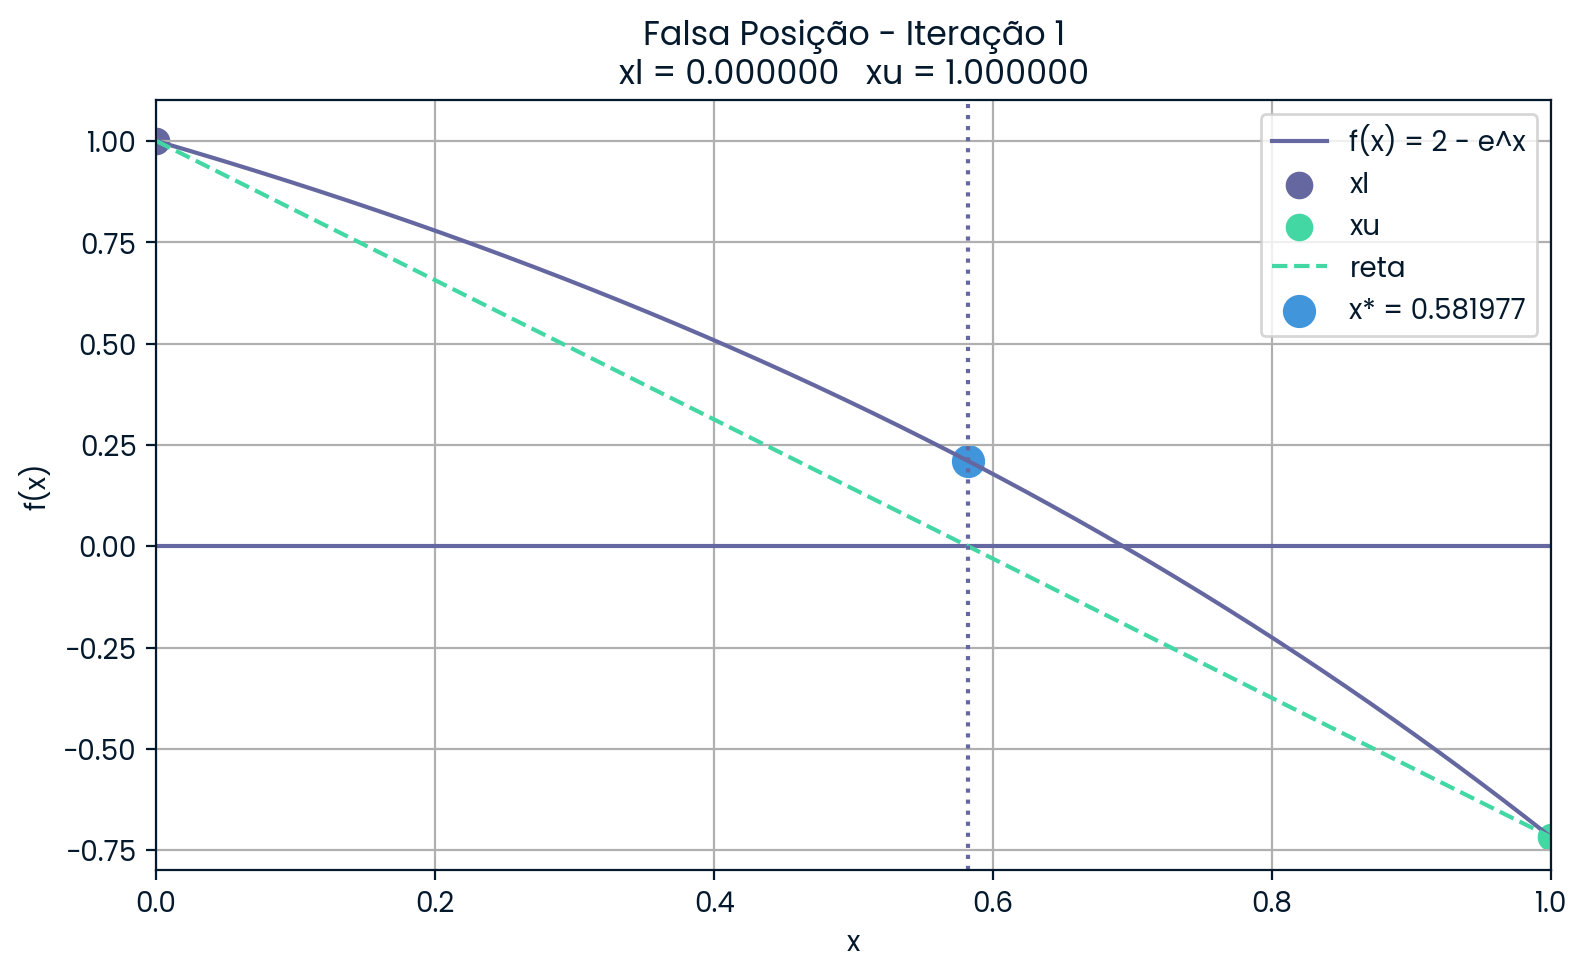

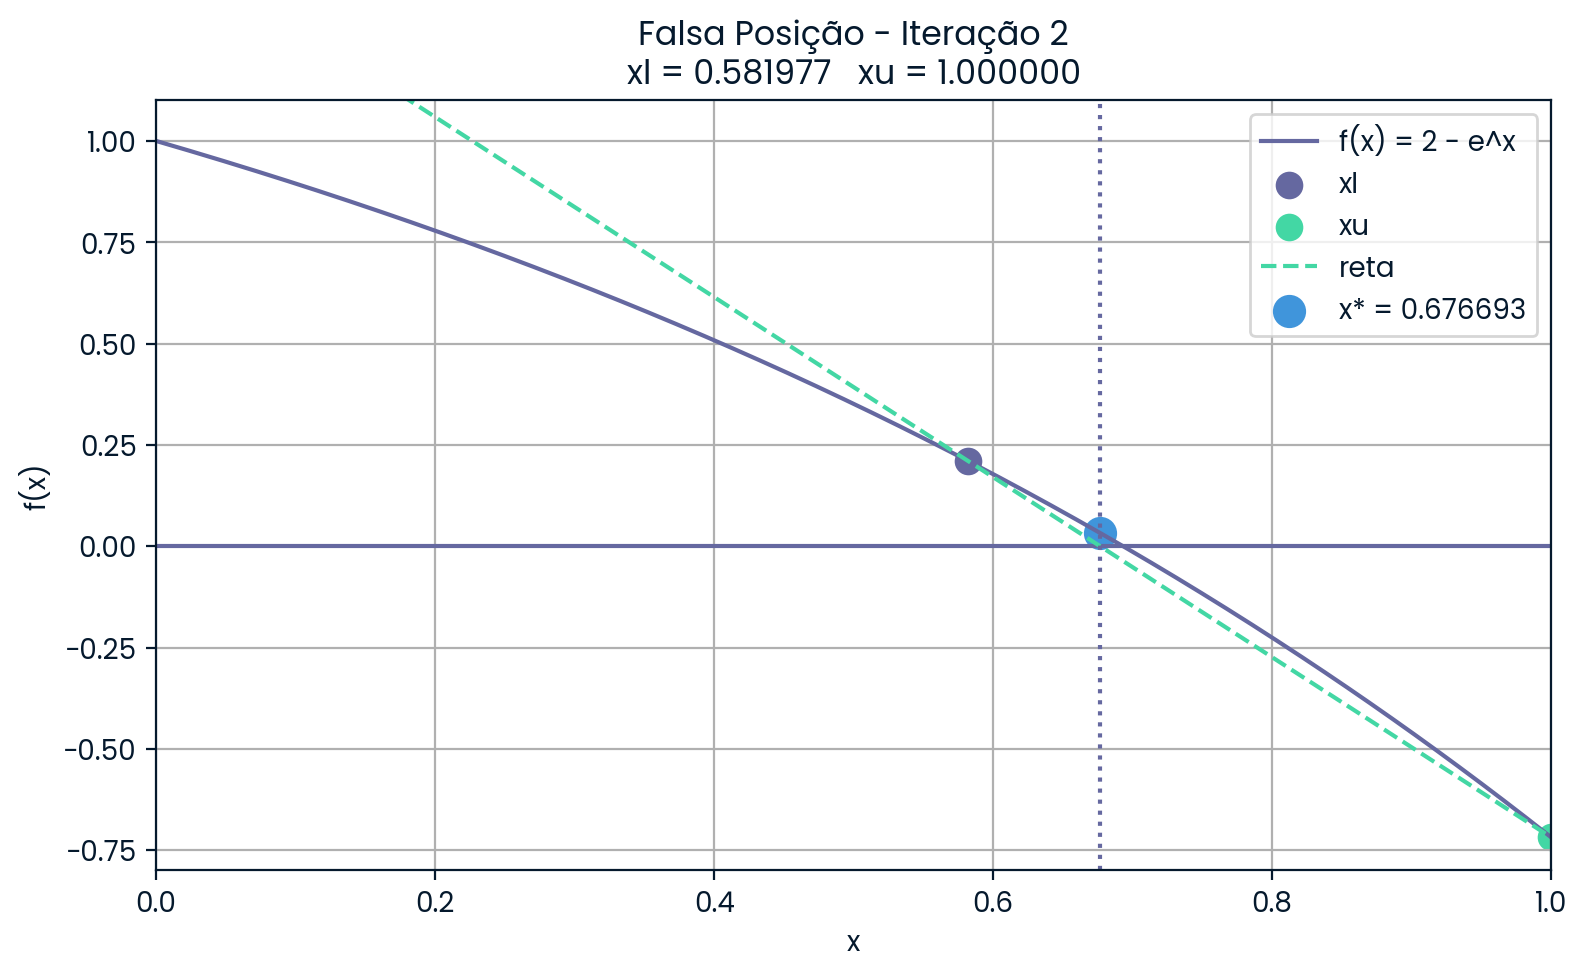

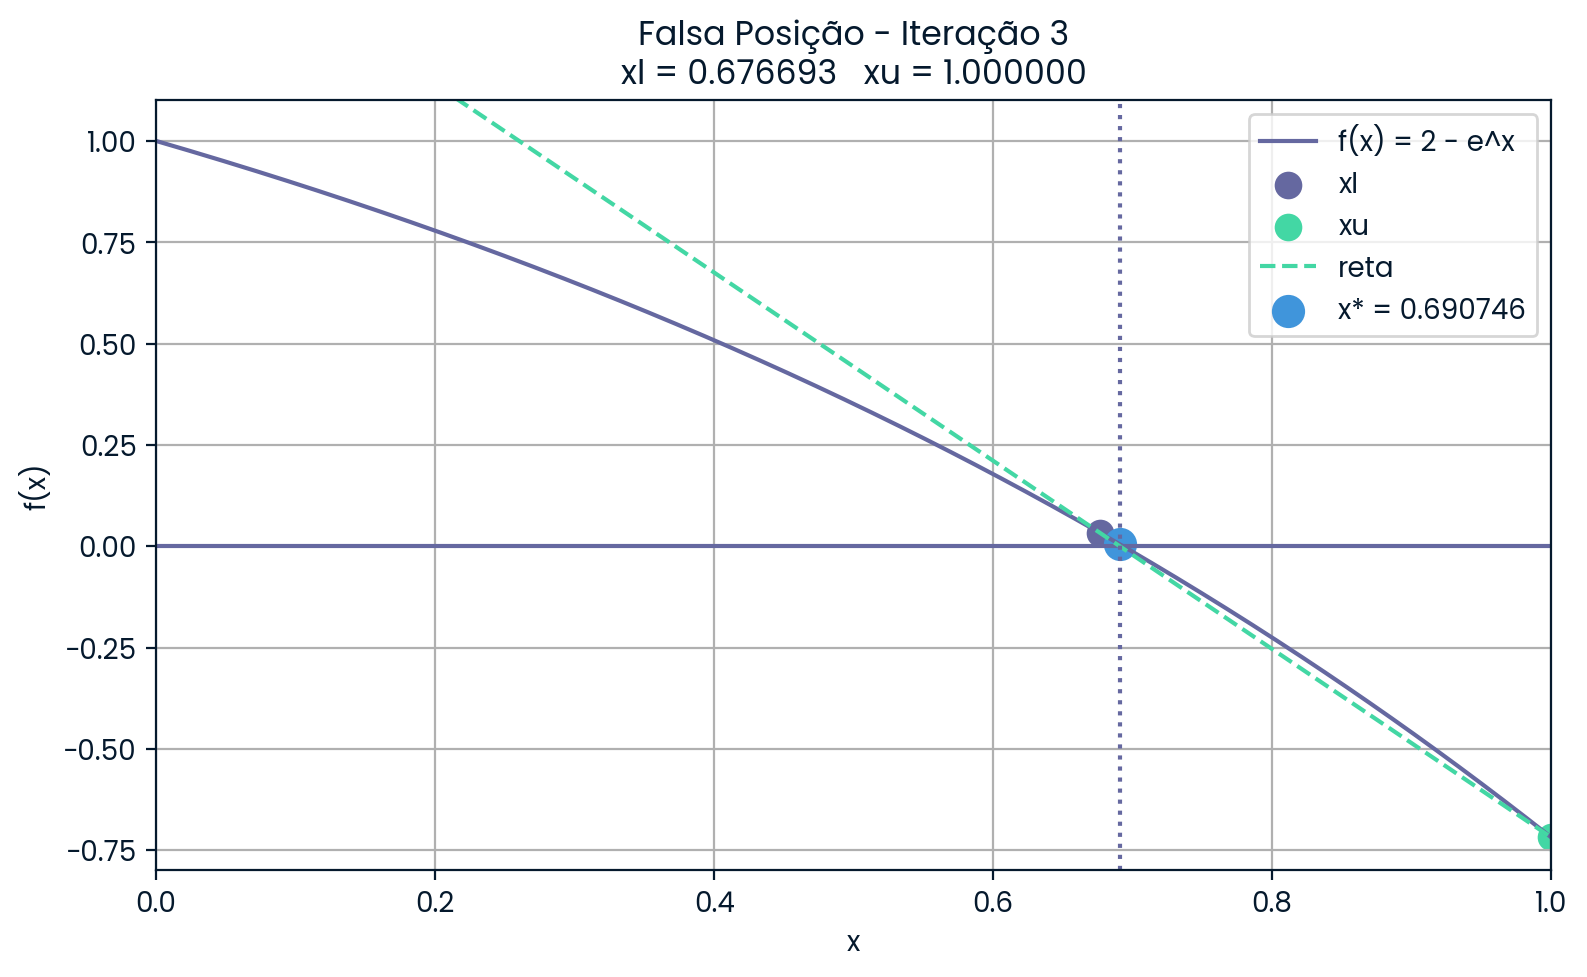

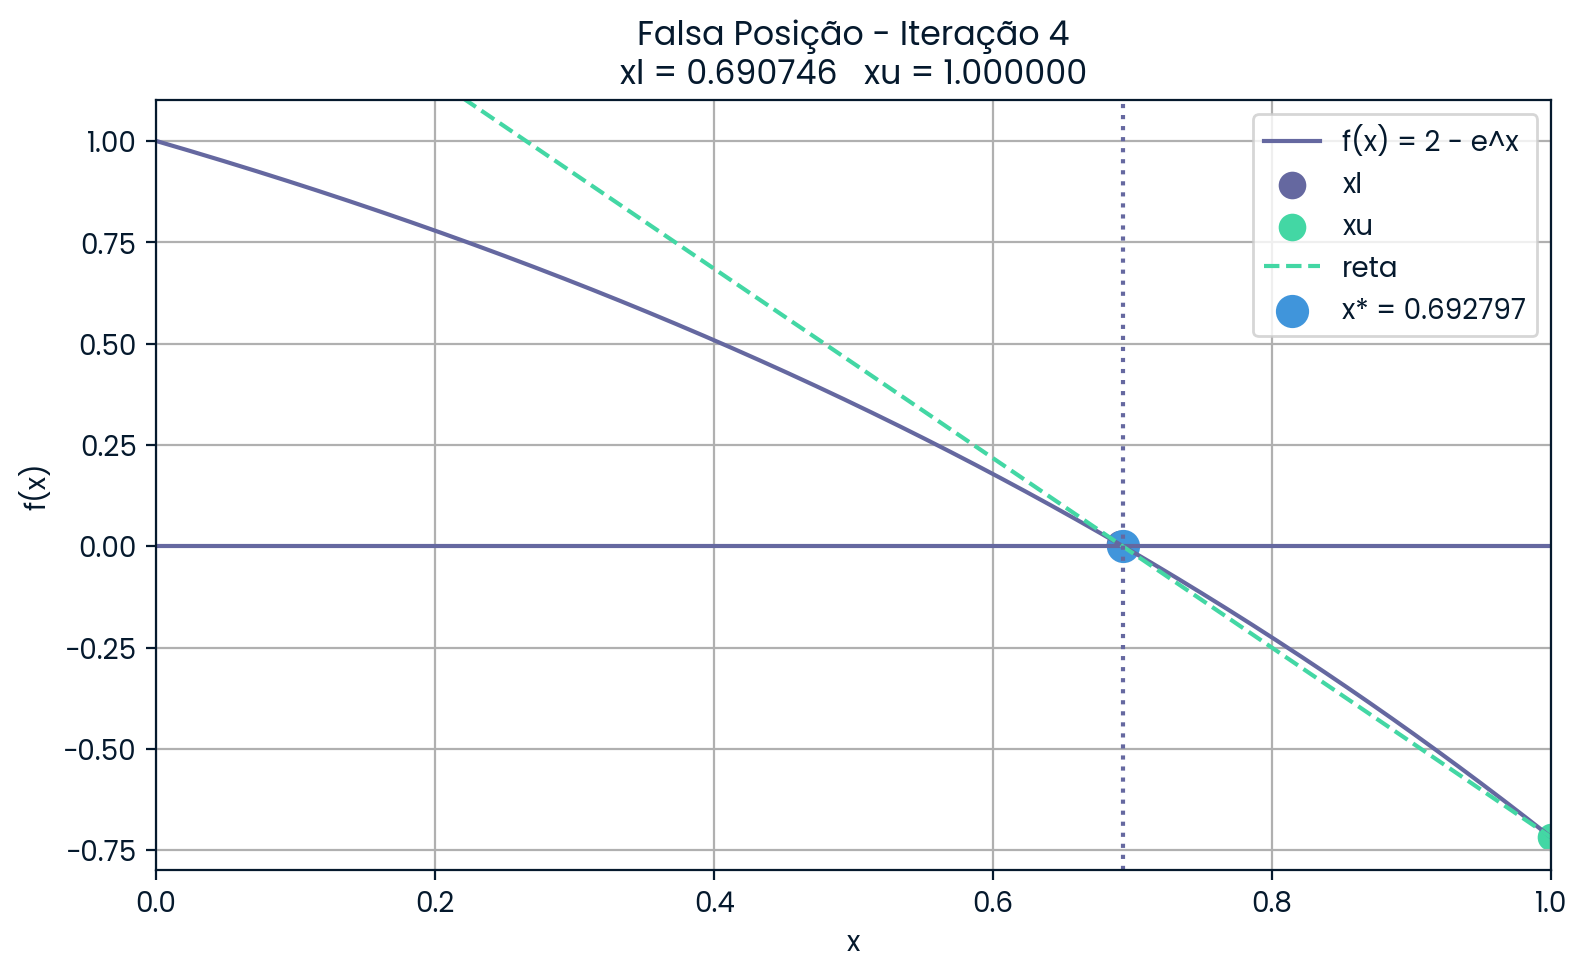

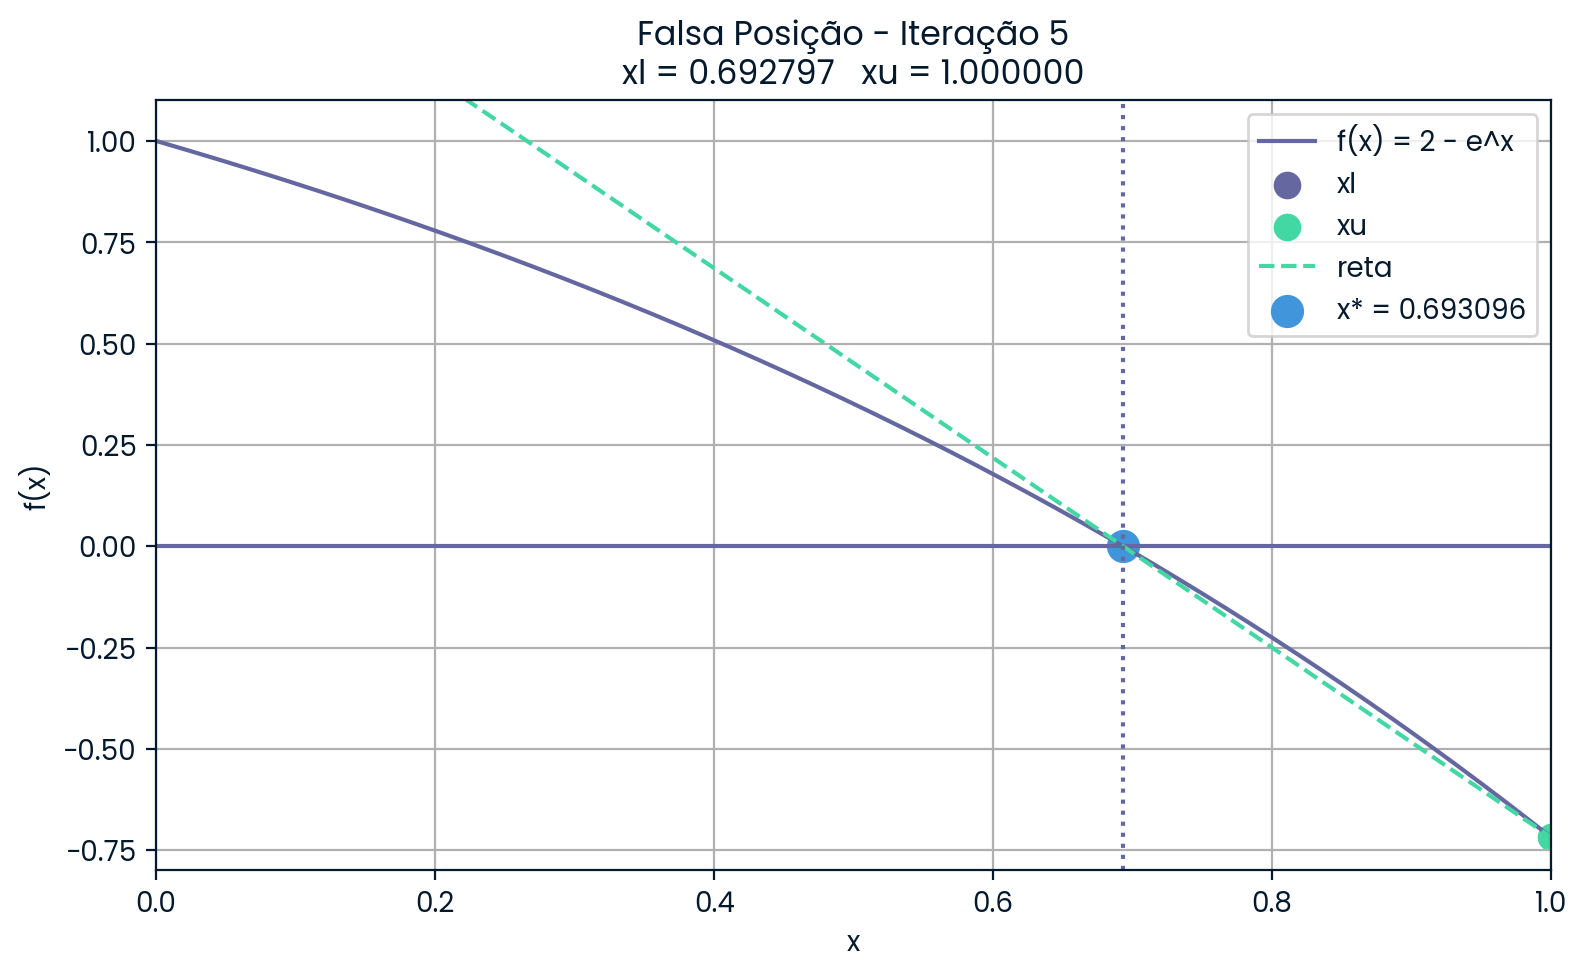

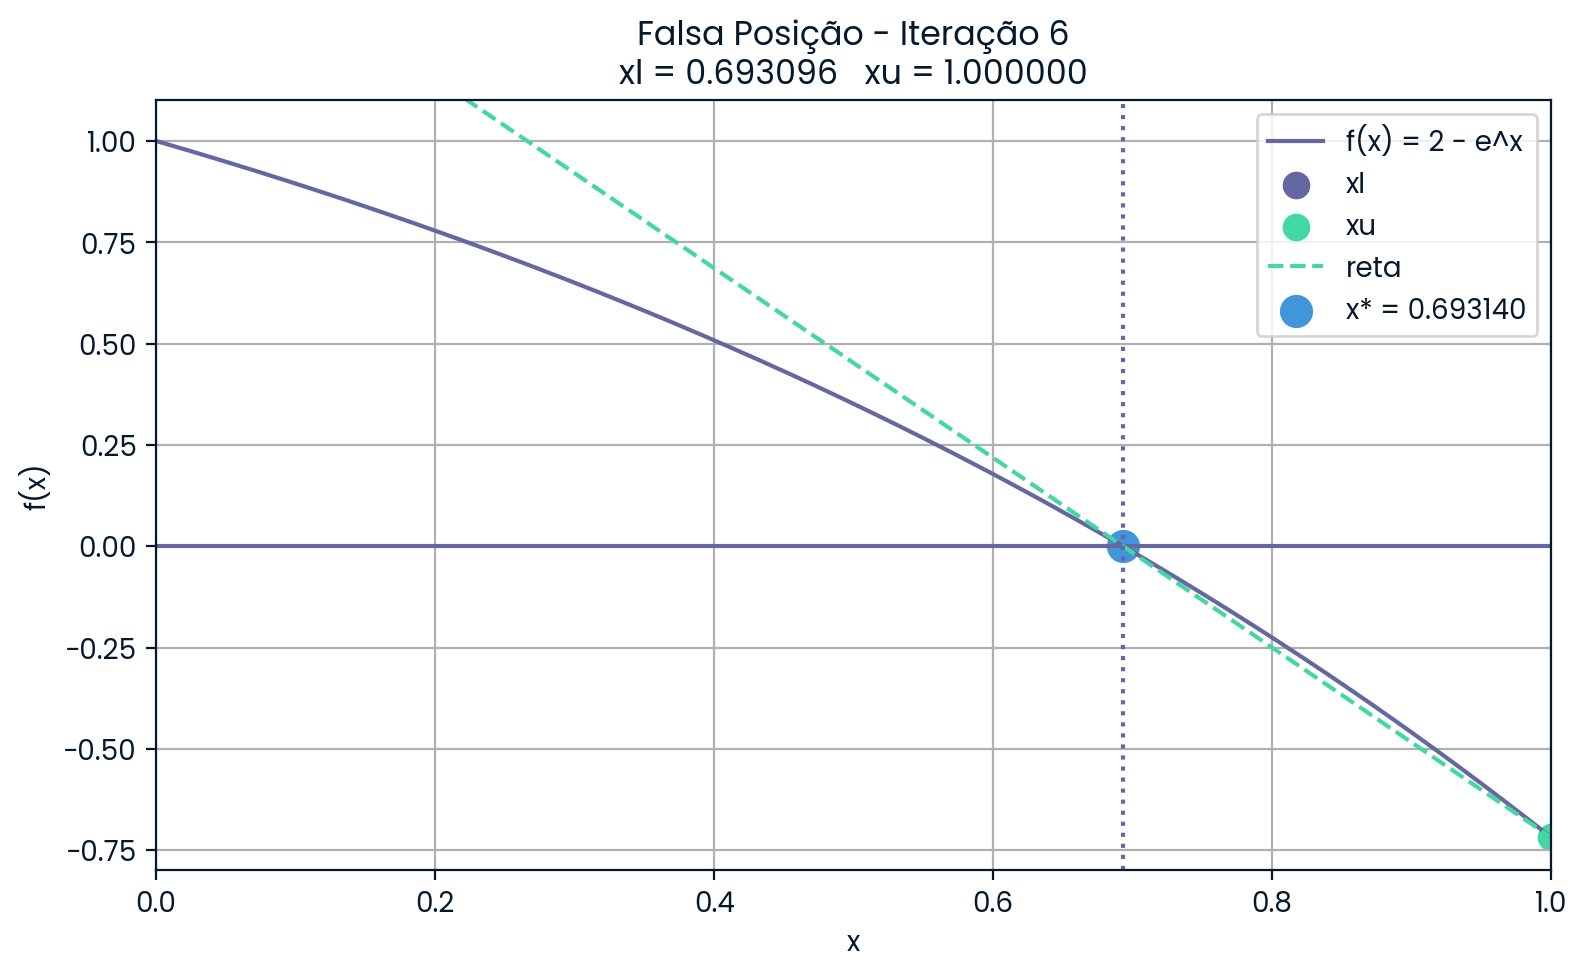

In [306]:
import numpy as np
import matplotlib.pyplot as plt


# ==========================================
# FUNÇÃO
# ==========================================

def f(x):
    return 2 - np.exp(x)


# ==========================================
# INTERVALO INICIAL
# ==========================================

xl = 0
xu = 1

tol = 0.0001


# ==========================================
# FALSA POSIÇÃO
# ==========================================

x_anterior = None

for i in range(10):

    fl = f(xl)
    fu = f(xu)

    # Fórmula da falsa posição
    x = xu - (fu * (xl - xu)) / (fl - fu)

    fx = f(x)

    # Erro
    if x_anterior is None:
        erro = None
    else:
        erro = abs((x - x_anterior) / x)

    # ==========================================
    # GRÁFICO
    # ==========================================

    xx = np.linspace(0, 1, 500)
    yy = f(xx)

    plt.figure(figsize=(9, 5))

    # Função
    plt.plot(xx, yy, label="f(x) = 2 - e^x")

    # Eixo x
    plt.axhline(0)

    # Pontos extremos
    plt.scatter(xl, fl, s=80, label="xl")
    plt.scatter(xu, fu, s=80, label="xu")

    # ==========================================
    # RETA DA FALSA POSIÇÃO
    # ==========================================

    # Coeficiente angular
    m = (fu - fl) / (xu - xl)

    # Equação da reta
    reta = fl + m * (xx - xl)

    plt.plot(
        xx,
        reta,
        "--",
        label="reta"
    )

    # ==========================================
    # PONTO x*
    # ==========================================

    plt.scatter(
        x,
        fx,
        s=120,
        label=f"x* = {x:.6f}"
    )

    # Linha vertical
    plt.axvline(
        x,
        linestyle=":"
    )

    # Configurações
    plt.xlim(0, 1)
    plt.ylim(-0.8, 1.1)

    plt.xlabel("x")
    plt.ylabel("f(x)")

    plt.title(
        f"Falsa Posição - Iteração {i + 1}\n"
        f"xl = {xl:.6f}   xu = {xu:.6f}"
    )

    plt.grid()
    plt.legend()

    plt.show()

    # ==========================================
    # ATUALIZA O INTERVALO
    # ==========================================

    if fl * fx < 0:
        xu = x
    else:
        xl = x

    # Critério de parada
    if erro is not None and erro < tol:
        break

    x_anterior = x